# 🌦️ Majira AI: 7-Day Weather Forecast with LSTM
This notebook uses LSTM to forecast temperature and rainfall for the next 7 days using 30 days of historical data.

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [2]:

df = pd.read_csv("Nairobi 2023-2025.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()
df.head()

,tempmax,tempmin,temp,dew,humidity,precip,windspeed,windspeedmax,windspeedmin,winddir,sealevelpressure,cloudcover,visibility
datetime,,,,,,,,,,,,,
2023-01-01,26.0,14.8,20.1,10.6,56.7,0.0,36.2,36.2,0.5,75.5,1022.6,51.6,10.3
2023-01-02,23.0,14.8,18.5,11.8,66.2,0.0,36.5,36.5,1.3,75.5,1022.2,66.4,10.3
2023-01-03,22.1,16.0,18.5,14.0,76.1,0.0,38.3,38.3,1.7,73.0,1022.5,75.1,10.0
2023-01-04,21.1,16.0,17.9,14.2,80.1,0.0,27.7,27.7,1.1,68.3,1022.4,83.6,10.1
2023-01-05,24.0,14.9,18.6,11.3,65.5,0.0,31.7,31.7,1.1,54.1,1022.0,70.8,10.1


In [3]:

data = df[['temp', 'precip']].copy()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [4]:

def create_7_day_sequences(data, input_window=30, forecast_horizon=7):
    X, y = [], []
    for i in range(len(data) - input_window - forecast_horizon + 1):
        X.append(data[i:i+input_window])
        y.append(data[i+input_window:i+input_window+forecast_horizon])
    return np.array(X), np.array(y)

X, y = create_7_day_sequences(scaled_data)
X.shape, y.shape


((786, 30, 2), (786, 7, 2))

In [5]:

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train.shape, y_train.shape


((628, 30, 2), (628, 7, 2))

In [6]:

model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7 * 2))  # 7 days * 2 features
model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,086 (199.55 KB)

 Trainable params: 51,086 (199.55 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

y_train_flat = y_train.reshape((y_train.shape[0], y_train.shape[1] * y_train.shape[2]))
y_test_flat = y_test.reshape((y_test.shape[0], y_test.shape[1] * y_test.shape[2]))


In [8]:

history = model.fit(X_train, y_train_flat, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.1207 - val_loss: 0.0172
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0324 - val_loss: 0.0090
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0234 - val_loss: 0.0088
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0235 - val_loss: 0.0086
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0204 - val_loss: 0.0083
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0204 - val_loss: 0.0086
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0206 - val_loss: 0.0093
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0195 - val_loss: 0.0086
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0190 - val_loss: 0.0088
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0166 - val_loss: 0.0085
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0172 - val_loss: 0.0091
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0

In [9]:

predictions = model.predict(X_test)
predictions = predictions.reshape((-1, 7, 2))
predicted_values = scaler.inverse_transform(predictions.reshape(-1, 2))
actual_values = scaler.inverse_transform(y_test.reshape(-1, 2))


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


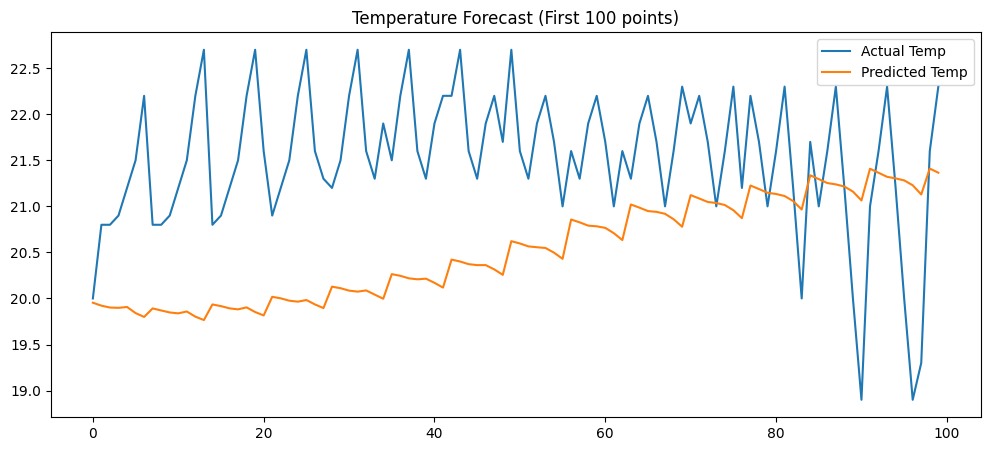

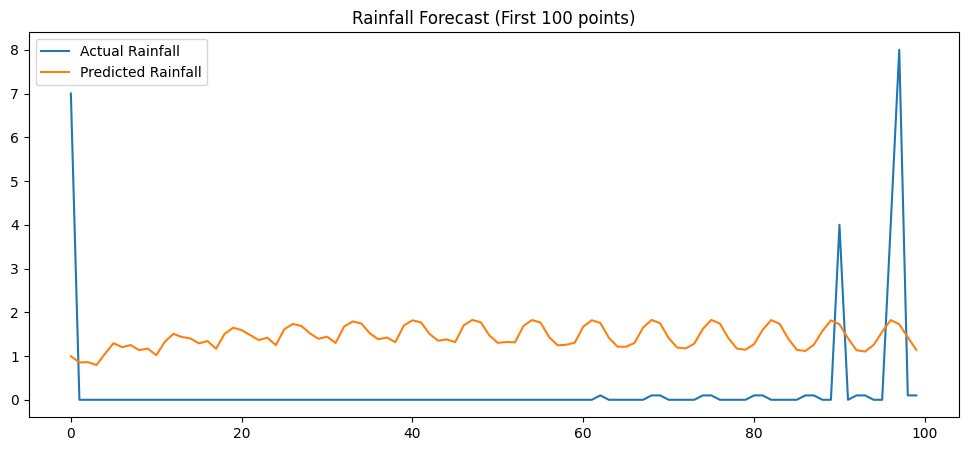

In [10]:

plt.figure(figsize=(12, 5))
plt.plot(actual_values[:100, 0], label='Actual Temp')
plt.plot(predicted_values[:100, 0], label='Predicted Temp')
plt.title("Temperature Forecast (First 100 points)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(actual_values[:100, 1], label='Actual Rainfall')
plt.plot(predicted_values[:100, 1], label='Predicted Rainfall')
plt.title("Rainfall Forecast (First 100 points)")
plt.legend()
plt.show()


## 📅 Weekly Average Forecast: Temperature & Rainfall
This section predicts the average temperature and rainfall over the next 7 days using the past 30 days as input.

In [11]:

def create_weekly_avg_targets(data, input_window=30, forecast_horizon=7):
    X, y = [], []
    for i in range(len(data) - input_window - forecast_horizon + 1):
        X.append(data[i:i+input_window])
        next_week = data[i+input_window:i+input_window+forecast_horizon]
        weekly_avg = np.mean(next_week, axis=0)  # avg temp & precip
        y.append(weekly_avg)
    return np.array(X), np.array(y)

X_weekly, y_weekly = create_weekly_avg_targets(scaled_data)
split = int(0.8 * len(X_weekly))
X_train_w, X_test_w = X_weekly[:split], X_weekly[split:]
y_train_w, y_test_w = y_weekly[:split], y_weekly[split:]
X_train_w.shape, y_train_w.shape


((628, 30, 2), (628, 2))

In [12]:

model_weekly = Sequential()
model_weekly.add(LSTM(64, activation='relu', input_shape=(X_train_w.shape[1], X_train_w.shape[2])))
model_weekly.add(Dropout(0.2))
model_weekly.add(Dense(2))  # 1 avg temp + 1 avg precip
model_weekly.compile(optimizer='adam', loss='mse')
model_weekly.summary()


C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,282 (67.51 KB)

 Trainable params: 17,282 (67.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:

history_weekly = model_weekly.fit(X_train_w, y_train_w, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1448 - val_loss: 0.0386
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0382 - val_loss: 0.0034
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0124 - val_loss: 0.0034
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0102 - val_loss: 0.0031
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0094 - val_loss: 0.0034
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0099 - val_loss: 0.0034
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0092 - val_loss: 0.0029
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0094 - val_loss: 0.0030
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0097 - val_loss: 0.0030
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0085 - val_loss: 0.0033
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0085 - val_loss: 0.0035
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


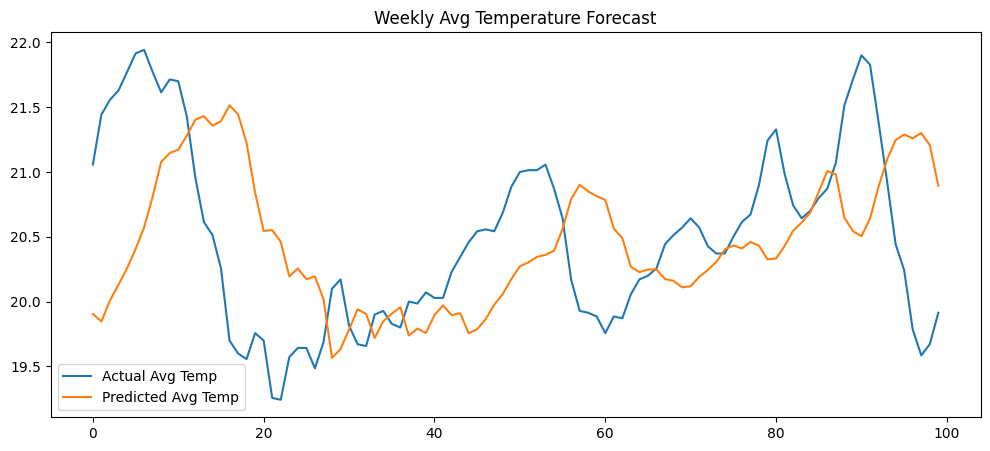

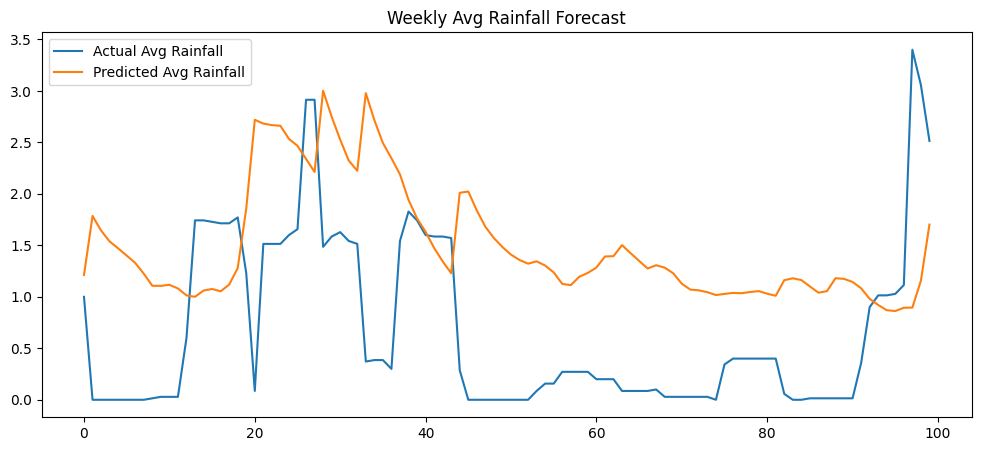

In [16]:
# Predict weekly averages
pred_weekly = model_weekly.predict(X_test_w)

# Pad with dummy zeros to match original 2-feature shape if needed
def pad_for_inverse_transform(data, feature_count=2):
    if data.shape[1] == feature_count:
        return data
    padded = np.zeros((data.shape[0], feature_count))
    padded[:, :data.shape[1]] = data
    return padded

# Apply fix for inverse_transform
pred_weekly_padded = pad_for_inverse_transform(pred_weekly)
y_test_weekly_padded = pad_for_inverse_transform(y_test_w)

# Inverse transform
pred_weekly_inverse = scaler.inverse_transform(pred_weekly_padded)
actual_weekly_inverse = scaler.inverse_transform(y_test_weekly_padded)

# Plot weekly average temperature
plt.figure(figsize=(12, 5))
plt.plot(actual_weekly_inverse[:100, 0], label='Actual Avg Temp')
plt.plot(pred_weekly_inverse[:100, 0], label='Predicted Avg Temp')
plt.title("Weekly Avg Temperature Forecast")
plt.legend()
plt.show()

# Plot weekly average rainfall
plt.figure(figsize=(12, 5))
plt.plot(actual_weekly_inverse[:100, 1], label='Actual Avg Rainfall')
plt.plot(pred_weekly_inverse[:100, 1], label='Predicted Avg Rainfall')
plt.title("Weekly Avg Rainfall Forecast")
plt.legend()
plt.show()


## 🚀 Improved 7-Day Forecast Model
This section improves the earlier model using Bidirectional LSTM, Huber loss, and more epochs for better trend and fluctuation learning.

In [19]:
from tensorflow.keras import Input
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.losses import Huber

model_improved = Sequential()
model_improved.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model_improved.add(Bidirectional(LSTM(64, activation='relu', return_sequences=True)))
model_improved.add(Dropout(0.2))
model_improved.add(Bidirectional(LSTM(64, activation='relu')))
model_improved.add(Dropout(0.2))
model_improved.add(Dense(7 * 2))  # 7 days * 2 features
model_improved.compile(optimizer='adam', loss=Huber())
model_improved.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 30, 128)             │          34,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 14)                  │           1,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,926 (527.05 KB)

 Trainable params: 134,926 (527.05 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

y_train_flat = y_train.reshape((y_train.shape[0], y_train.shape[1] * y_train.shape[2]))
y_test_flat = y_test.reshape((y_test.shape[0], y_test.shape[1] * y_test.shape[2]))


In [21]:

history_improved = model_improved.fit(X_train, y_train_flat, epochs=100, batch_size=32, validation_split=0.1)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - loss: 0.0658 - val_loss: 0.0079
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0149 - val_loss: 0.0043
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0112 - val_loss: 0.0042
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0087 - val_loss: 0.0043
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0088 - val_loss: 0.0042
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0084 - val_loss: 0.0051
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0087 - val_loss: 0.0045
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0083 - val_loss: 0.0042
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0084 - val_loss: 0.0048
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0078 - val_loss: 0.0048
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0073 - val_loss: 0.0050
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/st

In [22]:

pred_improved = model_improved.predict(X_test)
pred_improved = pred_improved.reshape((-1, 7, 2))
predicted_values_improved = scaler.inverse_transform(pred_improved.reshape(-1, 2))
actual_values_improved = scaler.inverse_transform(y_test.reshape(-1, 2))


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step


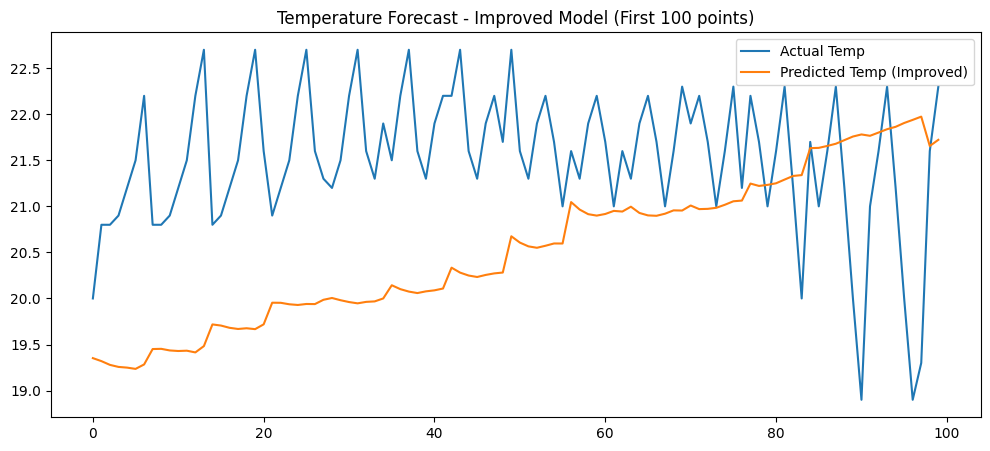

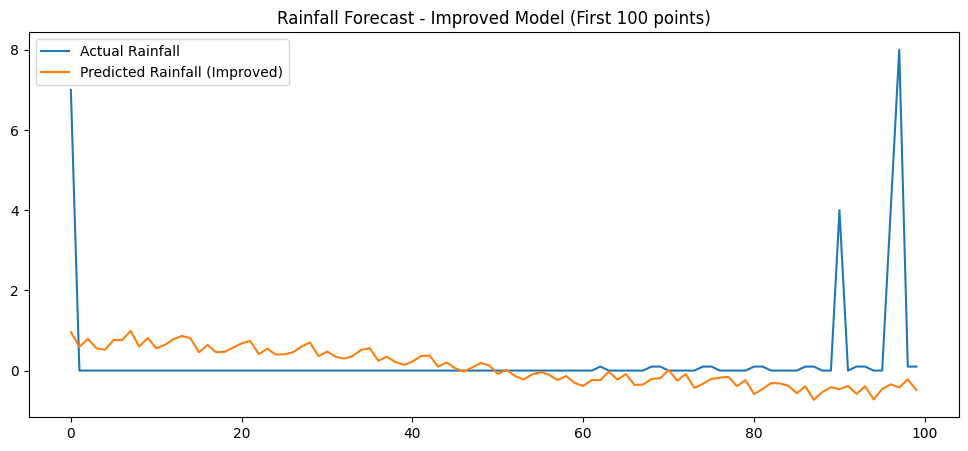

In [23]:

plt.figure(figsize=(12, 5))
plt.plot(actual_values_improved[:100, 0], label='Actual Temp')
plt.plot(predicted_values_improved[:100, 0], label='Predicted Temp (Improved)')
plt.title("Temperature Forecast - Improved Model (First 100 points)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(actual_values_improved[:100, 1], label='Actual Rainfall')
plt.plot(predicted_values_improved[:100, 1], label='Predicted Rainfall (Improved)')
plt.title("Rainfall Forecast - Improved Model (First 100 points)")
plt.legend()
plt.show()
